# Phase 3: Baseline Logistic Regression Model

Goal:
- Build a probability of default (PD) model
- Use logistic regression as a baseline
- Evaluate using ROC-AUC, PR-AUC, and calibration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_excel("/Users/jacobcheng/Projects/credit_risk_project/data/raw/credit_card_clients_raw.xls", header=1)
df = df.rename(columns={"default payment next month": "default_next_month"})
df = df.drop(columns=["ID"])

target_col = "default_next_month"

In [5]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [7]:
print(len(X_train), len(X_val), len(X_test))

21000 4500 4500


In [8]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
ordinal_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

numeric_cols = ["LIMIT_BAL", "AGE"] + bill_cols + payment_cols

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("ord", "passthrough", ordinal_cols),
        ("cat", "passthrough", categorical_cols)
    ]
)

In [10]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [11]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [12]:
y_val_probs = model.predict_proba(X_val)[:, 1]
y_test_probs = model.predict_proba(X_test)[:, 1]

In [13]:
val_auc = roc_auc_score(y_val, y_val_probs)
test_auc = roc_auc_score(y_test, y_test_probs)

print("Validation ROC-AUC:", val_auc)
print("Test ROC-AUC:", test_auc)

Validation ROC-AUC: 0.712962530197349
Test ROC-AUC: 0.7169124557591096


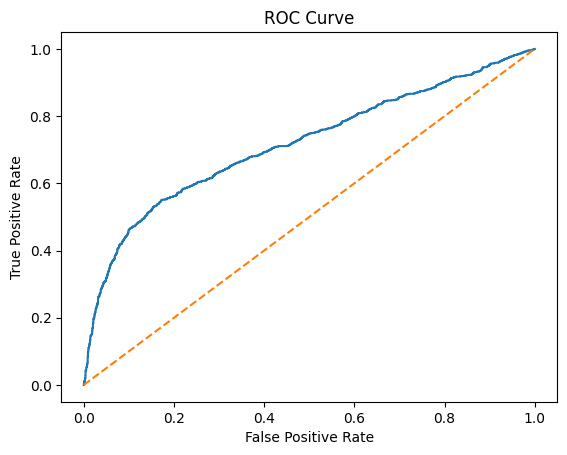

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

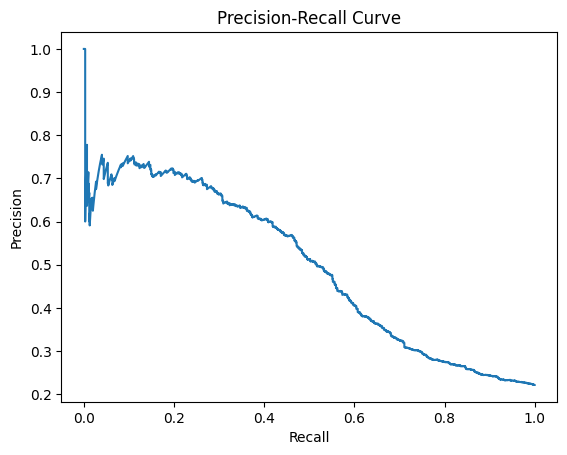

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [16]:
y_pred = (y_test_probs >= 0.5).astype(int)

confusion_matrix(y_test, y_pred)

array([[3405,   99],
       [ 764,  232]])

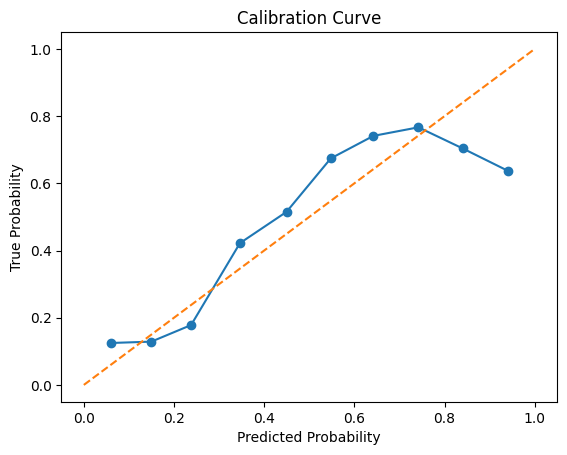

In [17]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_test_probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()

In [18]:
feature_names = numeric_cols + ordinal_cols + categorical_cols

coeffs = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coeffs
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
14,PAY_0,0.581930
4,BILL_AMT3,0.104348
15,PAY_2,0.086149
16,PAY_3,0.072575
1,AGE,0.058321
17,PAY_4,0.049663
5,BILL_AMT4,0.045317
7,BILL_AMT6,0.045126
19,PAY_6,0.019612
18,PAY_5,0.013570


In [19]:
coef_df.tail(10)

,feature,coefficient
12,PAY_AMT5,-0.026787
13,PAY_AMT6,-0.038190
11,PAY_AMT4,-0.044901
20,SEX,-0.105888
0,LIMIT_BAL,-0.117280
21,EDUCATION,-0.120999
22,MARRIAGE,-0.150651
8,PAY_AMT1,-0.151030
9,PAY_AMT2,-0.253071
2,BILL_AMT1,-0.309662


## Model Interpretation

- Positive coefficients increase probability of default
- Negative coefficients decrease probability of default

Key observations:
- Repayment status variables have strong positive coefficients → higher delinquency increases default risk
- Some financial variables show weaker or mixed effects
- Demographic variables tend to be less influential than repayment history

## Phase 3 Summary

- Logistic regression was used as a baseline PD model
- Model performance is evaluated using ROC-AUC and PR curves
- The dataset is imbalanced, so PR metrics are important
- Calibration analysis shows whether predicted probabilities are reliable
- Repayment history is the strongest predictor of default

Next step:
- compare against a tree-based model
- improve feature engineering
- refine preprocessing (encoding, scaling)